# Q5 historical descriptive analysis

**Research question**

Over the next six years, how will the proportion of people in London’s boroughs who frequently volunteer in sport change across different age groups and activity levels? Do the predicted differences between people with different activity levels vary by age group?

This notebook describes the six historical survey years before forecasting.

The analysis is conducted at the same borough-based levels used in the forecasting tasks:

- borough–age;
- borough–activity;
- borough–age–activity.

The exploratory analysis focuses on historical borough heterogeneity, subgroup temporal patterns, borough-specific historical change, age-dependent activity-level gaps, and changes in between-borough disparity.

## Module 1 — Configuration and load the historical panels

This module defines the historical survey years, subgroup ordering, input files and output folders.

The analysis uses the three complete historical panels already constructed for Q5:

- `borough × age × activity`;
- `borough × age`;
- `borough × activity`.

Only observed cells are used for descriptive rate calculations. Unobserved cells remain missing and are never treated as zero.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter


DATASET_DIR = Path(
    "/Users/zsh/Downloads/PROJECT/code/q4_dataset_outputs"
)

Q5_OUTPUT_DIR = Path(
    "/Users/zsh/Downloads/PROJECT/code/q4_historical_outputs"
)

FIGURE_DIR = (
    Q5_OUTPUT_DIR
    / "descriptive_figures"
)

TABLE_DIR = (
    Q5_OUTPUT_DIR
    / "descriptive_tables"
)

BOROUGH_AGE_ACTIVITY_PATH = (
    DATASET_DIR
    / "q5_versionA_borough_age_activitylevel_panel_complete.csv"
)

BOROUGH_AGE_PATH = (
    DATASET_DIR
    / "q5_versionA_borough_age_panel_complete.csv"
)

BOROUGH_ACTIVITY_PATH = (
    DATASET_DIR
    / "q5_versionA_borough_activitylevel_panel_complete.csv"
)

BOROUGH_MAPPING_PATH = (
    DATASET_DIR
    / "london_borough_code_mapping.xlsx"
)

YEAR_ORDER = [
    3,
    4,
    5,
    6,
    7,
    8,
]

YEAR_LABELS = {
    3: "2017/18",
    4: "2018/19",
    5: "2019/20",
    6: "2020/21",
    7: "2021/22",
    8: "2022/23",
}

HISTORICAL_PERIOD_LABEL = (
    f"{YEAR_LABELS[3]}–{YEAR_LABELS[8]}"
)

LAST_HISTORICAL_PERIOD_LABEL = (
    YEAR_LABELS[8]
)

AGE_ORDER = [
    "16-24",
    "25-34",
    "35-44",
    "45-54",
    "55-64",
    "65-74",
    "75-84",
    "85+",
]

ACTIVITY_ORDER = [
    "inactive",
    "fairly_active",
    "active",
]

ACTIVITY_DISPLAY = {
    "inactive": "Inactive",
    "fairly_active": "Fairly active",
    "active": "Active",
}

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

input_paths = [
    BOROUGH_AGE_ACTIVITY_PATH,
    BOROUGH_AGE_PATH,
    BOROUGH_ACTIVITY_PATH,
    BOROUGH_MAPPING_PATH,
]

for input_path in input_paths:
    if not input_path.exists():
        raise FileNotFoundError(
            f"File not found: {input_path}"
        )


borough_age_activity_panel = (
    pd.read_csv(
        BOROUGH_AGE_ACTIVITY_PATH,
        low_memory=False,
    )
)

borough_age_panel = (
    pd.read_csv(
        BOROUGH_AGE_PATH,
        low_memory=False,
    )
)

borough_activity_panel = (
    pd.read_csv(
        BOROUGH_ACTIVITY_PATH,
        low_memory=False,
    )
)

borough_mapping = (
    pd.read_excel(
        BOROUGH_MAPPING_PATH,
        sheet_name=(
            "London Borough Codes"
        ),
        header=None,
        names=[
            "LA_2023",
            "borough_gss_code",
            "borough_name",
        ],
    )
)

borough_mapping[
    "LA_2023"
] = (
    pd.to_numeric(
        borough_mapping[
            "LA_2023"
        ],
        errors="raise",
    )
    .astype(int)
)

if len(borough_mapping) != 32:
    raise ValueError(
        "The borough mapping must contain exactly 32 boroughs."
    )

if borough_mapping[
    "LA_2023"
].duplicated().any():
    raise ValueError(
        "Duplicate LA_2023 codes found in the borough mapping."
    )

BOROUGH_ORDER = (
    borough_mapping
    .sort_values(
        "borough_name"
    )[
        "borough_name"
    ]
    .tolist()
)

print(
    f"Borough mapping: "
    f"{len(borough_mapping)} boroughs"
)

print(
    f"Borough-age-activity panel: "
    f"{len(borough_age_activity_panel):,} rows"
)

print(
    f"Borough-age panel: "
    f"{len(borough_age_panel):,} rows"
)

print(
    f"Borough-activity panel: "
    f"{len(borough_activity_panel):,} rows"
)

Borough mapping: 32 boroughs
Borough-age-activity panel: 4,608 rows
Borough-age panel: 1,536 rows
Borough-activity panel: 576 rows


## Module 2 — Prepare the observed panels and helper functions

This module prepares the three observed historical panels and preserves the predefined age and activity-level ordering.

All descriptive summaries are calculated from borough-level panel estimates. Therefore, London-wide respondent pooling is not used in the following modules.

Reusable plotting and slope-estimation functions are also defined here.

In [2]:
def parse_nullable_boolean(
    series,
):
    text_values = (
        series
        .astype("string")
        .str.strip()
        .str.lower()
    )

    return text_values.map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    ).astype("boolean")


boolean_columns = [
    "small_cell",
    "few_frequent_cases",
    "zero_frequent_cases",
    "cell_observed",
    "rate_available",
    "series_has_history",
    "series_complete_history",
]

panel_frames = {
    "borough_age_activity":
        borough_age_activity_panel,
    "borough_age":
        borough_age_panel,
    "borough_activity":
        borough_activity_panel,
}

for panel in panel_frames.values():
    for column in boolean_columns:
        if column in panel.columns:
            panel[
                column
            ] = (
                parse_nullable_boolean(
                    panel[
                        column
                    ]
                )
            )

    if "age_group" in panel.columns:
        panel[
            "age_group"
        ] = pd.Categorical(
            panel[
                "age_group"
            ],
            categories=AGE_ORDER,
            ordered=True,
        )

    if (
        "activity_level_3cat_label"
        in panel.columns
    ):
        panel[
            "activity_level_3cat_label"
        ] = pd.Categorical(
            panel[
                "activity_level_3cat_label"
            ],
            categories=ACTIVITY_ORDER,
            ordered=True,
        )


borough_age_activity_observed_panel = (
    borough_age_activity_panel.loc[
        borough_age_activity_panel[
            "cell_observed"
        ].fillna(False)
    ]
    .copy()
)

borough_age_observed_panel = (
    borough_age_panel.loc[
        borough_age_panel[
            "cell_observed"
        ].fillna(False)
    ]
    .copy()
)

borough_activity_observed_panel = (
    borough_activity_panel.loc[
        borough_activity_panel[
            "cell_observed"
        ].fillna(False)
    ]
    .copy()
)


print(
    f"Borough-age-activity observed cells: "
    f"{len(borough_age_activity_observed_panel):,}"
)

print(
    f"Borough-age observed cells: "
    f"{len(borough_age_observed_panel):,}"
)

print(
    f"Borough-activity observed cells: "
    f"{len(borough_activity_observed_panel):,}"
)

def add_borough_names(
    data,
):
    return (
        data
        .merge(
            borough_mapping[
                [
                    "LA_2023",
                    "borough_name",
                ]
            ],
            on="LA_2023",
            how="left",
            validate="many_to_one",
        )
    )


def save_figure(
    fig,
    filename,
):
    output_path = (
        FIGURE_DIR
        / filename
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    print(
        f"Saved figure: "
        f"{output_path}"
    )
    
def first_quartile(
    series,
):
    return series.quantile(
        0.25
    )

def third_quartile(
    series,
):
    return series.quantile(
        0.75
    )
    
def plot_matrix_heatmap(
    data,
    row_column,
    column_column,
    value_column,
    row_order,
    column_order,
    title,
    xlabel,
    ylabel,
    colorbar_label,
    filename,
    figsize,
    row_labels=None,
    column_labels=None,
    value_multiplier=100,
    diverging=False,
    annotate=False,
):
    matrix = (
        data
        .pivot(
            index=row_column,
            columns=column_column,
            values=value_column,
        )
        .reindex(
            index=row_order,
            columns=column_order,
        )
    )

    display_matrix = (
        matrix
        * value_multiplier
    )

    values = (
        display_matrix
        .to_numpy(
            dtype=float
        )
    )

    finite_values = (
        values[
            np.isfinite(values)
        ]
    )

    if len(finite_values) == 0:
        raise ValueError(
            "No finite values are available for the heatmap."
        )

    if diverging:
        colour_limit = max(
            np.abs(
                finite_values
            ).max(),
            0.01,
        )

        vmin = (
            -colour_limit
        )

        vmax = (
            colour_limit
        )

        cmap = (
            "coolwarm"
        )

    else:
        vmin = 0

        vmax = max(
            finite_values.max(),
            0.01,
        )

        cmap = (
            "viridis"
        )

    fig, ax = plt.subplots(
        figsize=figsize
    )

    image = ax.imshow(
        values,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks(
        range(
            len(
                column_order
            )
        )
    )

    if column_labels is None:
        column_tick_labels = (
            column_order
        )

    else:
        column_tick_labels = [
            column_labels[
                value
            ]
            for value
            in column_order
        ]

    ax.set_xticklabels(
        column_tick_labels
    )

    ax.set_yticks(
        range(
            len(
                row_order
            )
        )
    )

    if row_labels is None:
        row_tick_labels = (
            row_order
        )

    else:
        row_tick_labels = [
            row_labels[
                value
            ]
            for value
            in row_order
        ]

    ax.set_yticklabels(
        row_tick_labels
    )

    if annotate:
        for row_index in range(
            display_matrix.shape[0]
        ):
            for column_index in range(
                display_matrix.shape[1]
            ):
                value = (
                    display_matrix.iloc[
                        row_index,
                        column_index,
                    ]
                )

                if pd.notna(value):
                    ax.text(
                        column_index,
                        row_index,
                        f"{value:.1f}",
                        ha="center",
                        va="center",
                    )

    ax.set_title(
        title
    )

    ax.set_xlabel(
        xlabel
    )

    ax.set_ylabel(
        ylabel
    )

    fig.colorbar(
        image,
        ax=ax,
        label=colorbar_label,
    )

    fig.tight_layout()

    save_figure(
        fig,
        filename,
    )
    
    plt.show()

Borough-age-activity observed cells: 4,290
Borough-age observed cells: 1,523
Borough-activity observed cells: 576


## Module 3 — Borough historical baseline

This module describes the borough-level subgroup profile at the final observed survey year.

Year 8 is used rather than a six-year historical average because it represents the direct historical starting point of the future forecasting period.

Two baseline matrices are examined:

- borough × age;
- borough × activity level.

The heatmaps show whether boroughs entered the forecasting period with similar or heterogeneous subgroup volunteering profiles.

In [3]:
year8_borough_age = (
    borough_age_observed_panel.loc[
        borough_age_observed_panel[
            "year"
        ]
        == 8,
        [
            "year",
            "LA_2023",
            "age_group_code",
            "age_group",
            "frequent_volunteer_rate",
        ],
    ]
    .copy()
)

year8_borough_age = (
    add_borough_names(
        year8_borough_age
    )
)

year8_borough_age = (
    year8_borough_age
    .sort_values(
        [
            "borough_name",
            "age_group_code",
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Year 8 borough-age cells: "
    f"{len(year8_borough_age):,}"
)

print(
    "Boroughs represented: "
    f"{year8_borough_age['LA_2023'].nunique()}"
)

year8_borough_age.head()

Year 8 borough-age cells: 255
Boroughs represented: 32


,year,LA_2023,age_group_code,age_group,frequent_volunteer_rate,borough_name
0,8,8,2,16-24,0.140795,Barking and Dagenham
1,8,8,3,25-34,0.011863,Barking and Dagenham
2,8,8,4,35-44,0.084793,Barking and Dagenham
3,8,8,5,45-54,0.054559,Barking and Dagenham
4,8,8,6,55-64,0.021952,Barking and Dagenham


Figure 1: Year 8 frequent volunteering rate by borough and age group

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_01_2022_23_borough_age_heatmap.png


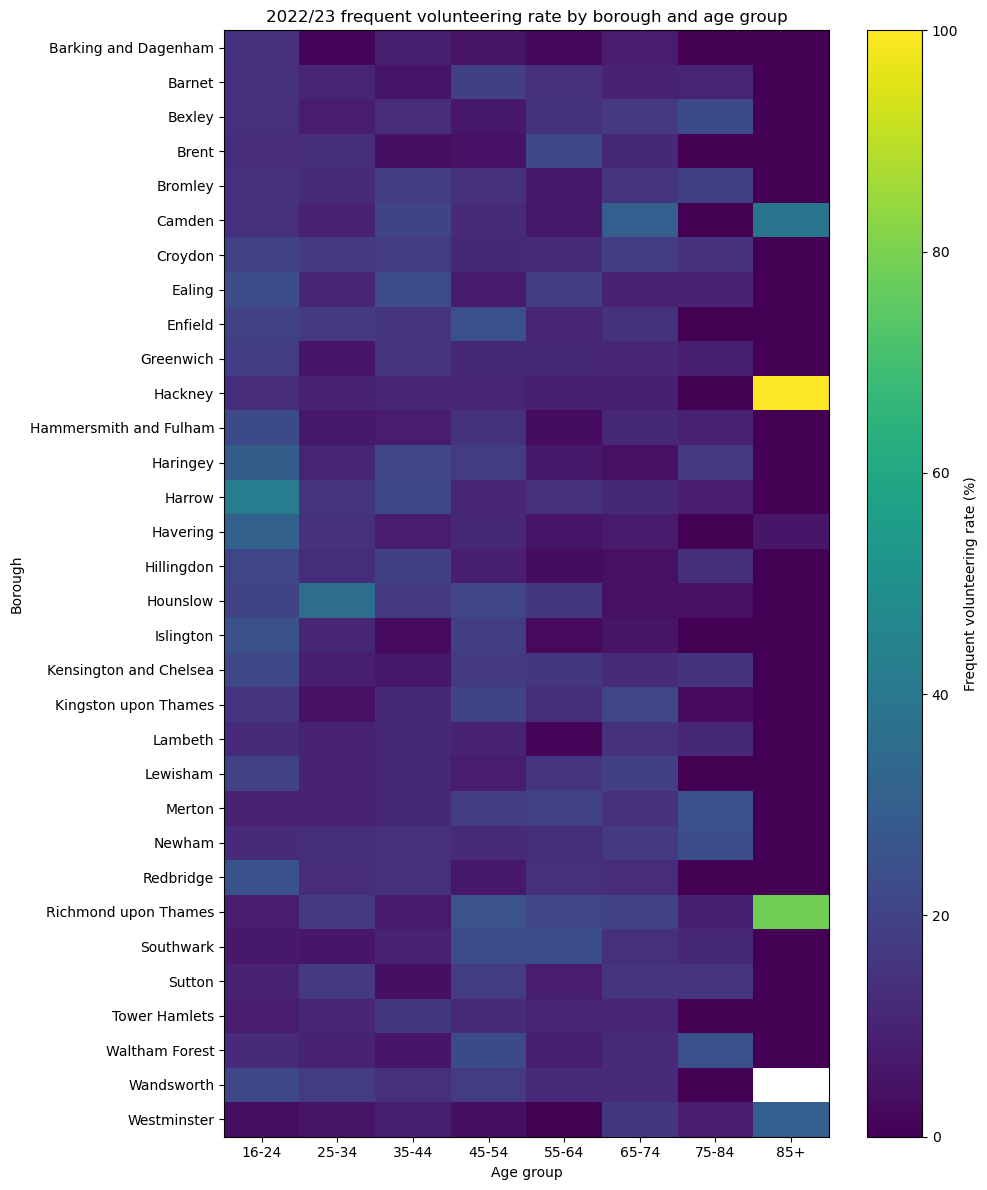

In [4]:
plot_matrix_heatmap(
    data=year8_borough_age,
    row_column="borough_name",
    column_column="age_group",
    value_column=(
        "frequent_volunteer_rate"
    ),
    row_order=BOROUGH_ORDER,
    column_order=AGE_ORDER,
    title=(
        f"{LAST_HISTORICAL_PERIOD_LABEL} frequent volunteering rate "
        "by borough and age group"
    ),
    xlabel="Age group",
    ylabel="Borough",
    colorbar_label=(
        "Frequent volunteering rate (%)"
    ),
    filename=(
        "figure_01_2022_23_borough_age_heatmap.png"
    ),
    figsize=(10, 12),
)

In [5]:
year8_borough_activity = (
    borough_activity_observed_panel.loc[
        borough_activity_observed_panel[
            "year"
        ]
        == 8,
        [
            "year",
            "LA_2023",
            "activity_level_3cat",
            "activity_level_3cat_label",
            "frequent_volunteer_rate",
        ],
    ]
    .copy()
)

year8_borough_activity = (
    add_borough_names(
        year8_borough_activity
    )
)

year8_borough_activity = (
    year8_borough_activity
    .sort_values(
        [
            "borough_name",
            "activity_level_3cat",
        ]
    )
    .reset_index(
        drop=True
    )
)

print(
    "Year 8 borough-activity cells: "
    f"{len(year8_borough_activity):,}"
)

print(
    "Boroughs represented: "
    f"{year8_borough_activity['LA_2023'].nunique()}"
)

year8_borough_activity.head()

Year 8 borough-activity cells: 96
Boroughs represented: 32


,year,LA_2023,activity_level_3cat,activity_level_3cat_label,frequent_volunteer_rate,borough_name
0,8,8,0,inactive,0.017519,Barking and Dagenham
1,8,8,1,fairly_active,0.016830,Barking and Dagenham
2,8,8,2,active,0.118599,Barking and Dagenham
3,8,9,0,inactive,0.048331,Barnet
4,8,9,1,fairly_active,0.120685,Barnet


Figure 2: Year 8 frequent volunteering rate by borough and activity level

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_02_2022_23_borough_activity_heatmap.png


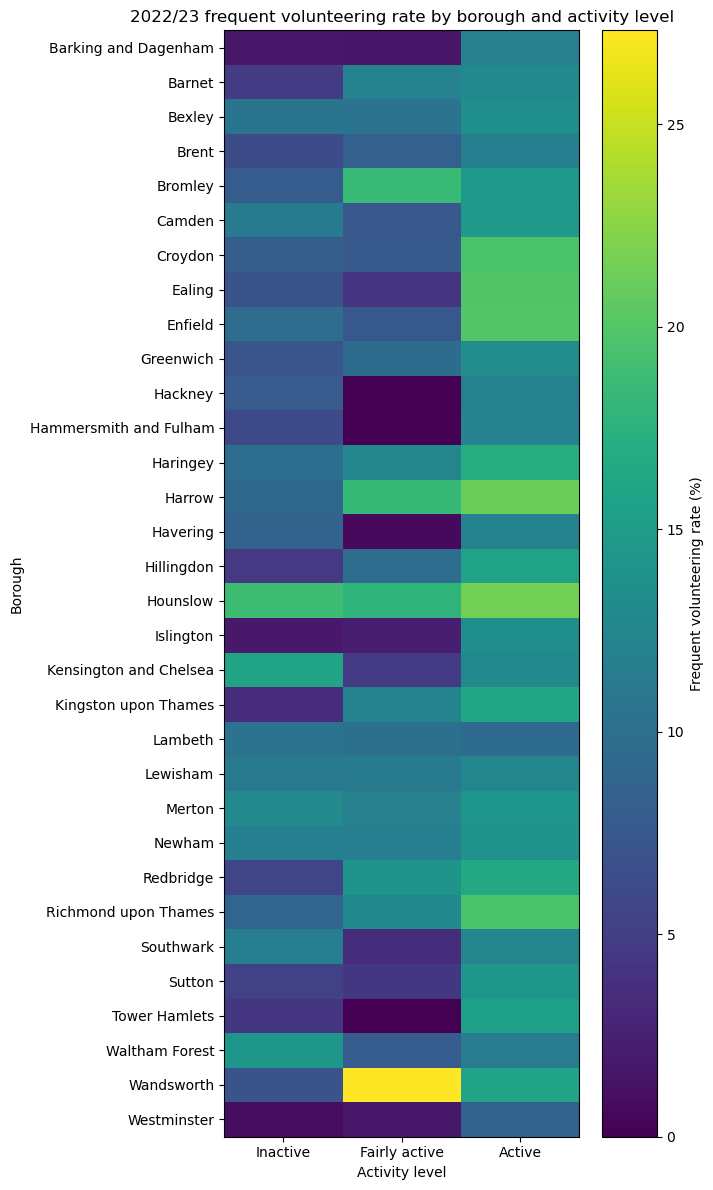

In [6]:
plot_matrix_heatmap(
    data=year8_borough_activity,
    row_column="borough_name",
    column_column=(
        "activity_level_3cat_label"
    ),
    value_column=(
        "frequent_volunteer_rate"
    ),
    row_order=BOROUGH_ORDER,
    column_order=ACTIVITY_ORDER,
    column_labels=(
        ACTIVITY_DISPLAY
    ),
    title=(
    f"{LAST_HISTORICAL_PERIOD_LABEL} frequent volunteering rate by borough and activity level"
    ),
    xlabel="Activity level",
    ylabel="Borough",
    colorbar_label=(
        "Frequent volunteering rate (%)"
    ),
    filename=(
        "figure_02_2022_23_borough_activity_heatmap.png"
    ),
    figsize=(7, 12),
)

## Module 4 — Historical subgroup temporal patterns

This module examines the central historical trajectory of borough-level frequent volunteering rates.

For each survey year and subgroup, the median is calculated across the available borough-level rates. Boroughs are therefore treated as the spatial analysis units rather than being pooled into a single London-wide population estimate.

The activity-level results are displayed as temporal trajectories, while the larger number of age groups is summarised using an age-by-year heatmap.

In [7]:
historical_activity_median = (
    borough_activity_observed_panel
    .groupby(
        [
            "year",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
        observed=True,
    )
    .agg(
        median_borough_rate=(
            "frequent_volunteer_rate",
            "median",
        ),
        boroughs_observed=(
            "LA_2023",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "year",
            "activity_level_3cat",
        ]
    )
)

historical_activity_median

,year,activity_level_3cat,activity_level_3cat_label,median_borough_rate,boroughs_observed
0,3,0,inactive,0.045945,32
1,3,1,fairly_active,0.045570,32
2,3,2,active,0.126492,32
3,4,0,inactive,0.027555,32
4,4,1,fairly_active,0.066253,32
5,4,2,active,0.122610,32
6,5,0,inactive,0.074861,32
7,5,1,fairly_active,0.094899,32
8,5,2,active,0.134645,32
9,6,0,inactive,0.047706,32


Figure 3: Median borough frequent volunteering rate by activity level

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_03_historical_activity_median.png


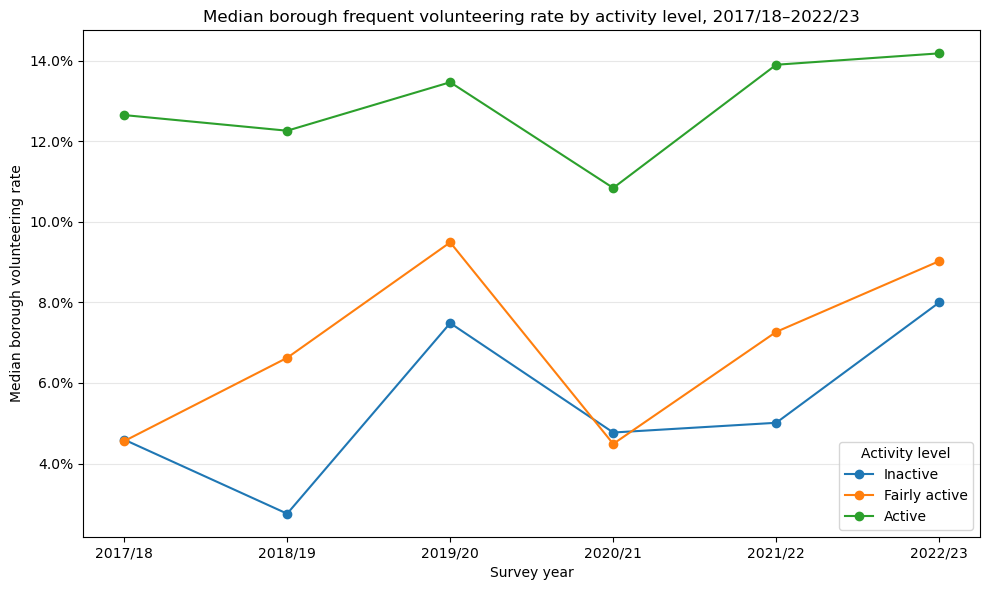

In [8]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

for activity_level in (
    ACTIVITY_ORDER
):
    subset = (
        historical_activity_median.loc[
            historical_activity_median[
                "activity_level_3cat_label"
            ]
            == activity_level
        ]
        .sort_values(
            "year"
        )
    )

    ax.plot(
        subset[
            "year"
        ],
        subset[
            "median_borough_rate"
        ],
        marker="o",
        label=(
            ACTIVITY_DISPLAY[
                activity_level
            ]
        ),
    )

ax.set_xticks(
    YEAR_ORDER
)

ax.set_xticklabels(
    [
        YEAR_LABELS[
            year
        ]
        for year
        in YEAR_ORDER
    ]
)

ax.set_title(
    f"Median borough frequent volunteering rate by activity level, {HISTORICAL_PERIOD_LABEL}"
)

ax.set_xlabel(
    "Survey year"
)

ax.set_ylabel(
    "Median borough volunteering rate"
)

ax.yaxis.set_major_formatter(
    PercentFormatter(
        1.0
    )
)

ax.legend(
    title="Activity level"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

save_figure(
    fig,
    "figure_03_historical_activity_median.png",
)

plt.show()

In [9]:
historical_age_median = (
    borough_age_observed_panel
    .groupby(
        [
            "year",
            "age_group_code",
            "age_group",
        ],
        observed=True,
    )
    .agg(
        median_borough_rate=(
            "frequent_volunteer_rate",
            "median",
        ),
        boroughs_observed=(
            "LA_2023",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "year",
            "age_group_code",
        ]
    )
)

historical_age_median

,year,age_group_code,age_group,median_borough_rate,boroughs_observed
0,3,2,16-24,0.150493,32
1,3,3,25-34,0.073069,32
2,3,4,35-44,0.078409,32
3,3,5,45-54,0.135028,32
4,3,6,55-64,0.080998,32
5,3,7,65-74,0.063085,32
6,3,8,75-84,0.066272,32
7,3,9,85+,0.000000,32
8,4,2,16-24,0.127641,32
9,4,3,25-34,0.077067,32


Figure 4: Median borough frequent volunteering rate by age group and survey year

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_04_historical_age_median_heatmap.png


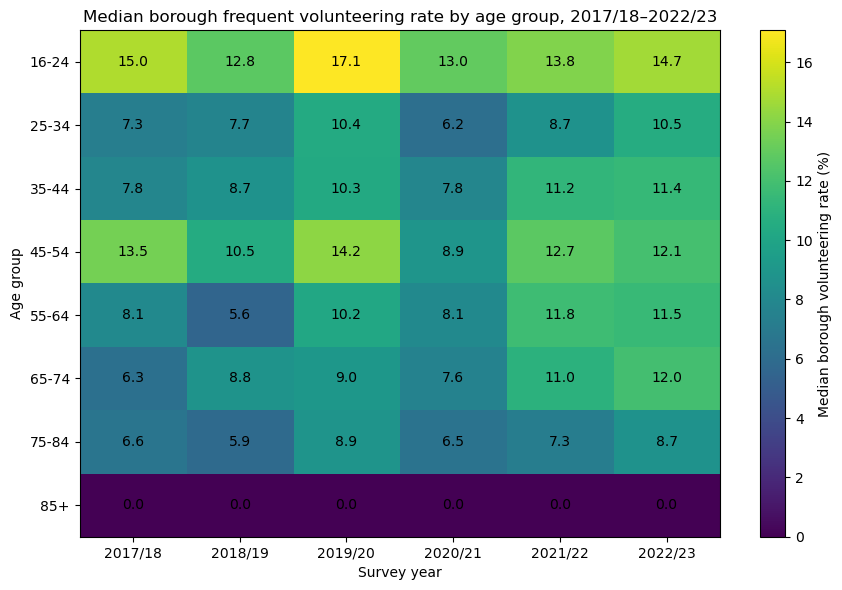

In [10]:
plot_matrix_heatmap(
    data=historical_age_median,
    row_column="age_group",
    column_column="year",
    value_column=(
        "median_borough_rate"
    ),
    row_order=AGE_ORDER,
    column_order=YEAR_ORDER,
    column_labels=YEAR_LABELS,
    title=(
        f"Median borough frequent volunteering rate by age group, {HISTORICAL_PERIOD_LABEL}"
    ),
    xlabel="Survey year",
    ylabel="Age group",
    colorbar_label=(
        "Median borough volunteering rate (%)"
    ),
    filename=(
        "figure_04_historical_age_median_heatmap.png"
    ),
    figsize=(9, 6),
    annotate=True,
)

## Module 5 — Borough-specific historical change

The previous module describes the central historical trajectory across London boroughs. This module examines whether individual boroughs and subgroups followed the same historical direction.

A separate descriptive linear trend is estimated for each borough–subgroup series:

`frequent_volunteer_rate = intercept + slope × year`

The slope is calculated only for series observed in all six historical survey periods from 2017/18 to 2022/23. Series with one or more missing survey periods are not assigned a slope, ensuring that all displayed slopes represent the same historical time window.

Each observed annual borough-level estimate receives equal weight. The slope is interpreted only as a descriptive summary of historical direction rather than as a long-term growth rate.

The 2017/18 to 2022/23 endpoint change is also retained as a supplementary descriptive measure.

In [11]:
def calculate_series_slopes(
    data,
    series_columns,
):
    rows = []

    required_years = set(
        YEAR_ORDER
    )

    for (
        series_values,
        series_data
    ) in data.groupby(
        series_columns,
        observed=True,
        dropna=False,
    ):
        if not isinstance(
            series_values,
            tuple,
        ):
            series_values = (
                series_values,
            )

        valid_data = (
            series_data[
                [
                    "year",
                    "frequent_volunteer_rate",
                ]
            ]
            .dropna()
            .sort_values(
                "year"
            )
        )

        row = dict(
            zip(
                series_columns,
                series_values,
            )
        )

        observed_years = set(
            valid_data[
                "year"
            ]
            .astype(int)
            .tolist()
        )

        row[
            "observed_years"
        ] = len(
            observed_years
        )

        row[
            "complete_historical_period"
        ] = (
            observed_years
            == required_years
        )

        if row[
            "complete_historical_period"
        ]:
            slope = (
                np.polyfit(
                    valid_data[
                        "year"
                    ].astype(float),
                    valid_data[
                        "frequent_volunteer_rate"
                    ].astype(float),
                    deg=1,
                )[0]
            )

        else:
            slope = np.nan

        row[
            "historical_slope"
        ] = slope

        year3_values = (
            valid_data.loc[
                valid_data[
                    "year"
                ]
                == 3,
                "frequent_volunteer_rate",
            ]
        )

        year8_values = (
            valid_data.loc[
                valid_data[
                    "year"
                ]
                == 8,
                "frequent_volunteer_rate",
            ]
        )

        row[
            "year3_rate"
        ] = (
            year3_values.iloc[0]
            if len(
                year3_values
            )
            == 1
            else np.nan
        )

        row[
            "year8_rate"
        ] = (
            year8_values.iloc[0]
            if len(
                year8_values
            )
            == 1
            else np.nan
        )

        if (
            pd.notna(
                row[
                    "year3_rate"
                ]
            )
            and pd.notna(
                row[
                    "year8_rate"
                ]
            )
        ):
            row[
                "year3_year8_change"
            ] = (
                row[
                    "year8_rate"
                ]
                - row[
                    "year3_rate"
                ]
            )

        else:
            row[
                "year3_year8_change"
            ] = np.nan

        rows.append(
            row
        )

    result = (
        pd.DataFrame(
            rows
        )
    )

    result[
        "slope_pp_per_year"
    ] = (
        result[
            "historical_slope"
        ]
        * 100
    )

    result[
        "year3_year8_change_pp"
    ] = (
        result[
            "year3_year8_change"
        ]
        * 100
    )

    return result

borough_activity_slopes = (
    calculate_series_slopes(
        data=(
            borough_activity_observed_panel
        ),
        series_columns=[
            "LA_2023",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
    )
)

borough_activity_slopes = (
    add_borough_names(
        borough_activity_slopes
    )
)

borough_activity_slopes = (
    borough_activity_slopes
    .sort_values(
        [
            "borough_name",
            "activity_level_3cat",
        ]
    )
    .reset_index(
        drop=True
    )
)

borough_activity_slopes.head()

,LA_2023,activity_level_3cat,activity_level_3cat_label,observed_years,complete_historical_period,historical_slope,year3_rate,year8_rate,year3_year8_change,slope_pp_per_year,year3_year8_change_pp,borough_name
0,8,0,inactive,6,True,-0.002788,0.023116,0.017519,-0.005597,-0.278784,-0.559700,Barking and Dagenham
1,8,1,fairly_active,6,True,-0.004775,0.023985,0.016830,-0.007155,-0.477488,-0.715473,Barking and Dagenham
2,8,2,active,6,True,0.009173,0.102177,0.118599,0.016422,0.917274,1.642192,Barking and Dagenham
3,9,0,inactive,6,True,-0.002161,0.050567,0.048331,-0.002236,-0.216101,-0.223637,Barnet
4,9,1,fairly_active,6,True,0.020895,0.027299,0.120685,0.093386,2.089549,9.338627,Barnet


Figure 5: Historical volunteering-rate slope by borough and activity level

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_05_borough_activity_slope_heatmap.png


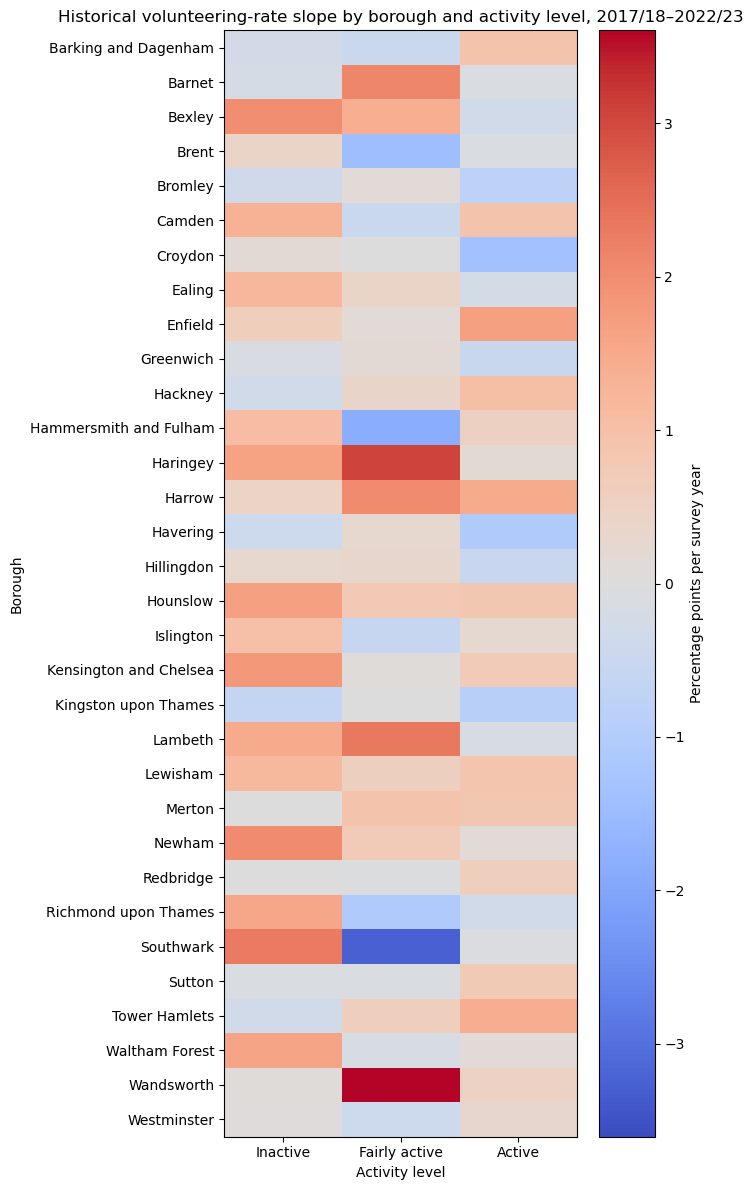

In [12]:
plot_matrix_heatmap(
    data=borough_activity_slopes,
    row_column="borough_name",
    column_column=(
        "activity_level_3cat_label"
    ),
    value_column=(
        "slope_pp_per_year"
    ),
    row_order=BOROUGH_ORDER,
    column_order=ACTIVITY_ORDER,
    column_labels=(
        ACTIVITY_DISPLAY
    ),
    title=(
        f"Historical volunteering-rate slope by borough and activity level, {HISTORICAL_PERIOD_LABEL}"
    ),
    xlabel="Activity level",
    ylabel="Borough",
    colorbar_label=(
        "Percentage points per survey year"
    ),
    filename=(
        "figure_05_borough_activity_slope_heatmap.png"
    ),
    figsize=(7, 12),
    value_multiplier=1,
    diverging=True,
)

In [13]:
borough_age_slopes = (
    calculate_series_slopes(
        data=(
            borough_age_observed_panel
        ),
        series_columns=[
            "LA_2023",
            "age_group_code",
            "age_group",
        ],
    )
)

borough_age_slopes = (
    add_borough_names(
        borough_age_slopes
    )
)

borough_age_slopes = (
    borough_age_slopes
    .sort_values(
        [
            "borough_name",
            "age_group_code",
        ]
    )
    .reset_index(
        drop=True
    )
)

borough_age_slopes.head()

,LA_2023,age_group_code,age_group,observed_years,complete_historical_period,historical_slope,year3_rate,year8_rate,year3_year8_change,slope_pp_per_year,year3_year8_change_pp,borough_name
0,8,2,16-24,6,True,0.016410,0.014016,0.140795,0.126780,1.641019,12.677954,Barking and Dagenham
1,8,3,25-34,6,True,-0.001237,0.035771,0.011863,-0.023908,-0.123713,-2.390788,Barking and Dagenham
2,8,4,35-44,6,True,0.007438,0.076888,0.084793,0.007905,0.743813,0.790493,Barking and Dagenham
3,8,5,45-54,6,True,-0.003766,0.145376,0.054559,-0.090817,-0.376569,-9.081691,Barking and Dagenham
4,8,6,55-64,6,True,-0.000114,0.035250,0.021952,-0.013298,-0.011365,-1.329804,Barking and Dagenham


Figure 6: Historical volunteering-rate slope by borough and age group

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_06_borough_age_slope_heatmap.png


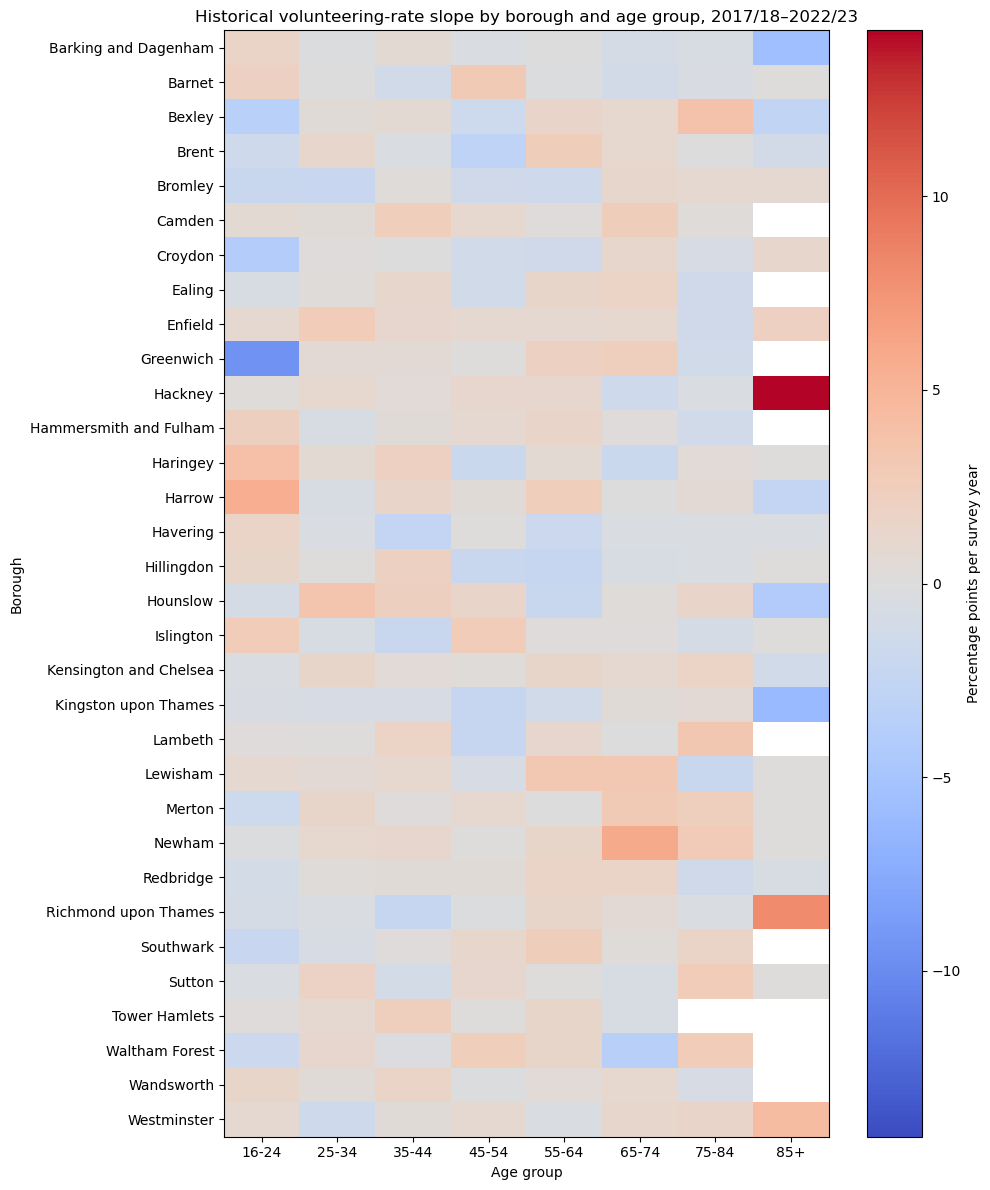

In [14]:
plot_matrix_heatmap(
    data=borough_age_slopes,
    row_column="borough_name",
    column_column="age_group",
    value_column=(
        "slope_pp_per_year"
    ),
    row_order=BOROUGH_ORDER,
    column_order=AGE_ORDER,
    title=(
        f"Historical volunteering-rate slope by borough and age group, {HISTORICAL_PERIOD_LABEL}"
    ),
    xlabel="Age group",
    ylabel="Borough",
    colorbar_label=(
        "Percentage points per survey year"
    ),
    filename=(
        "figure_06_borough_age_slope_heatmap.png"
    ),
    figsize=(10, 12),
    value_multiplier=1,
    diverging=True,
)

## Module 6 — Historical age × activity gap

This module examines whether the historical difference between active and inactive adults varied across age groups and survey periods.

The contrast is calculated within each borough–age–period combination:

`active–inactive gap = active frequent volunteering rate − inactive frequent volunteering rate`

A gap is calculated only when both activity-level rates are observed.

For each age group and survey period, the median gap is then calculated across the available London boroughs. This preserves the historical time dimension while summarising the typical borough-level activity gap.

The heatmap therefore describes how the active–inactive volunteering gap varied jointly across age groups and historical survey periods.

In [15]:
borough_age_year_activity_rates = (
    borough_age_activity_observed_panel
    .pivot_table(
        index=[
            "year",
            "LA_2023",
            "age_group_code",
            "age_group",
        ],
        columns=(
            "activity_level_3cat_label"
        ),
        values=(
            "frequent_volunteer_rate"
        ),
        observed=True,
    )
    .reset_index()
)

borough_age_year_activity_rates[
    "active_inactive_gap"
] = (
    borough_age_year_activity_rates[
        "active"
    ]
    - borough_age_year_activity_rates[
        "inactive"
    ]
)

borough_age_year_activity_rates[
    "fairly_inactive_gap"
] = (
    borough_age_year_activity_rates[
        "fairly_active"
    ]
    - borough_age_year_activity_rates[
        "inactive"
    ]
)

borough_age_year_activity_rates.head()

activity_level_3cat_label,year,LA_2023,age_group_code,age_group,inactive,fairly_active,active,active_inactive_gap,fairly_inactive_gap
0,3,8,2,16-24,0.000000,0.000000,0.023783,0.023783,0.000000
1,3,8,3,25-34,0.000000,0.000000,0.070900,0.070900,0.000000
2,3,8,4,35-44,0.033739,0.067342,0.116861,0.083122,0.033602
3,3,8,5,45-54,0.096651,0.000000,0.201810,0.105159,-0.096651
4,3,8,6,55-64,0.000000,0.000000,0.079329,0.079329,0.000000


In [16]:
historical_gap_by_age_year = (
    borough_age_year_activity_rates
    .groupby(
        [
            "year",
            "age_group_code",
            "age_group",
        ],
        observed=True,
    )
    .agg(
        median_active_inactive_gap=(
            "active_inactive_gap",
            "median",
        ),
        median_fairly_inactive_gap=(
            "fairly_inactive_gap",
            "median",
        ),
        boroughs_with_active_inactive_gap=(
            "active_inactive_gap",
            "count",
        ),
        boroughs_with_fairly_inactive_gap=(
            "fairly_inactive_gap",
            "count",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "year",
            "age_group_code",
        ]
    )
)

historical_gap_by_age_year

,year,age_group_code,age_group,median_active_inactive_gap,median_fairly_inactive_gap,boroughs_with_active_inactive_gap,boroughs_with_fairly_inactive_gap
0,3,2,16-24,0.144854,0.000000,29,28
1,3,3,25-34,0.059193,0.000000,32,32
2,3,4,35-44,0.079994,0.000000,32,32
3,3,5,45-54,0.157187,0.000000,32,32
4,3,6,55-64,0.088608,0.000000,32,32
5,3,7,65-74,0.070773,0.000000,32,31
6,3,8,75-84,0.082015,0.000000,32,30
7,3,9,85+,0.000000,0.000000,21,15
8,4,2,16-24,0.119306,0.000000,30,23
9,4,3,25-34,0.068607,0.000000,32,32


Figure 7: Median borough active–inactive volunteering gap by age group and survey year

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_07_historical_age_activity_gap_heatmap.png


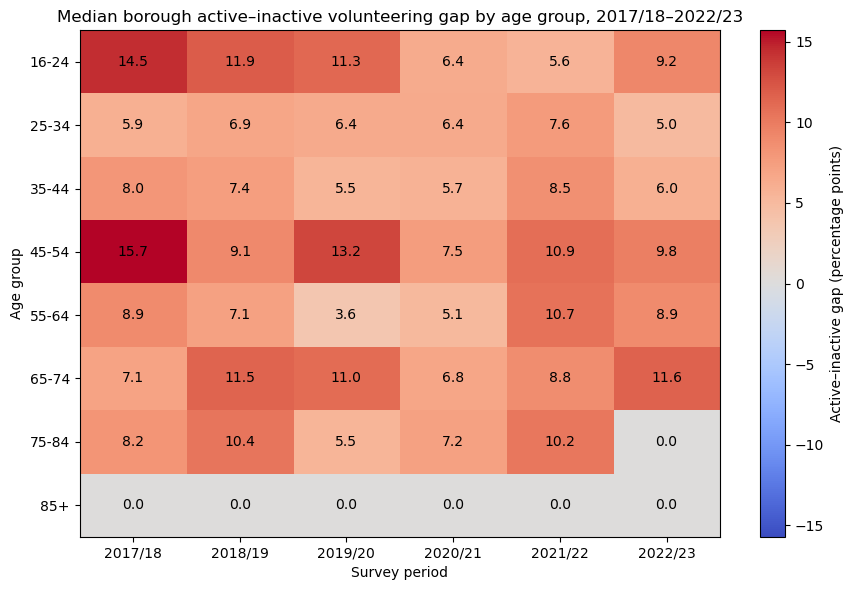

In [17]:
plot_matrix_heatmap(
    data=historical_gap_by_age_year,
    row_column="age_group",
    column_column="year",
    value_column=(
        "median_active_inactive_gap"
    ),
    row_order=AGE_ORDER,
    column_order=YEAR_ORDER,
    column_labels=YEAR_LABELS,
    title=(
        "Median borough active–inactive volunteering gap "
        f"by age group, {HISTORICAL_PERIOD_LABEL}"
    ),
    xlabel="Survey period",
    ylabel="Age group",
    colorbar_label=(
        "Active–inactive gap "
        "(percentage points)"
    ),
    filename=(
        "figure_07_historical_age_activity_gap_heatmap.png"
    ),
    figsize=(9, 6),
    value_multiplier=100,
    diverging=True,
    annotate=True,
)

## Module 7 — Between-borough dispersion over time

This module examines whether variation in borough-level volunteering rates widened, narrowed or remained broadly stable over the six historical survey periods.

For each survey period and subgroup, between-borough dispersion is measured using the interquartile range:

`IQR = 75th percentile borough rate − 25th percentile borough rate`

The IQR is preferred to the full range because it is less sensitive to unusually high or low individual borough estimates.

Activity-level dispersion is displayed as temporal trajectories. Age-specific dispersion is summarised in an age-by-period heatmap.

In [18]:
def summarise_borough_dispersion(
    data,
    group_columns,
):
    summary = (
        data
        .groupby(
            group_columns,
            observed=True,
        )
        .agg(
            boroughs_observed=(
                "LA_2023",
                "nunique",
            ),
            median_borough_rate=(
                "frequent_volunteer_rate",
                "median",
            ),
            q25_borough_rate=(
                "frequent_volunteer_rate",
                first_quartile,
            ),
            q75_borough_rate=(
                "frequent_volunteer_rate",
                third_quartile,
            ),
        )
        .reset_index()
    )

    summary[
        "borough_iqr"
    ] = (
        summary[
            "q75_borough_rate"
        ]
        - summary[
            "q25_borough_rate"
        ]
    )

    return summary

In [19]:
borough_disparity_activity = (
    summarise_borough_dispersion(
        data=(
            borough_activity_observed_panel
        ),
        group_columns=[
            "year",
            "activity_level_3cat",
            "activity_level_3cat_label",
        ],
    )
    .sort_values(
        [
            "year",
            "activity_level_3cat",
        ]
    )
)

borough_disparity_activity

,year,activity_level_3cat,activity_level_3cat_label,boroughs_observed,median_borough_rate,q25_borough_rate,q75_borough_rate,borough_iqr
0,3,0,inactive,32,0.045945,0.019020,0.067994,0.048974
1,3,1,fairly_active,32,0.045570,0.026636,0.099348,0.072712
2,3,2,active,32,0.126492,0.099000,0.159432,0.060432
3,4,0,inactive,32,0.027555,0.011036,0.054737,0.043700
4,4,1,fairly_active,32,0.066253,0.033038,0.093383,0.060345
5,4,2,active,32,0.122610,0.101864,0.160617,0.058753
6,5,0,inactive,32,0.074861,0.040691,0.097399,0.056708
7,5,1,fairly_active,32,0.094899,0.067479,0.128436,0.060956
8,5,2,active,32,0.134645,0.119656,0.159282,0.039626
9,6,0,inactive,32,0.047706,0.028286,0.075832,0.047546


Figure 8: Between-borough volunteering dispersion by activity level

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_08_activity_between_borough_iqr.png


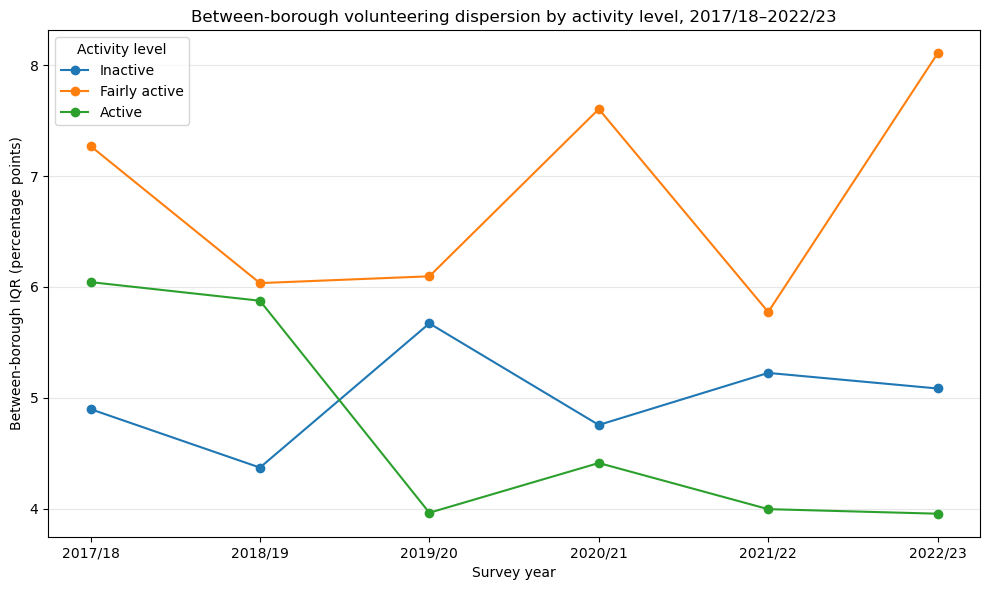

In [20]:
fig, ax = plt.subplots(
    figsize=(10, 6)
)

for activity_level in (
    ACTIVITY_ORDER
):
    subset = (
        borough_disparity_activity.loc[
            borough_disparity_activity[
                "activity_level_3cat_label"
            ]
            == activity_level
        ]
        .sort_values(
            "year"
        )
    )

    ax.plot(
        subset[
            "year"
        ],
        subset[
            "borough_iqr"
        ]
        * 100,
        marker="o",
        label=(
            ACTIVITY_DISPLAY[
                activity_level
            ]
        ),
    )

ax.set_xticks(
    YEAR_ORDER
)

ax.set_xticklabels(
    [
        YEAR_LABELS[
            year
        ]
        for year
        in YEAR_ORDER
    ]
)

ax.set_title(
    f"Between-borough volunteering dispersion by activity level, {HISTORICAL_PERIOD_LABEL}"
)

ax.set_xlabel(
    "Survey year"
)

ax.set_ylabel(
    "Between-borough IQR "
    "(percentage points)"
)

ax.legend(
    title="Activity level"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

fig.tight_layout()

save_figure(
    fig,
    "figure_08_activity_between_borough_iqr.png",
)

plt.show()

In [21]:
borough_disparity_age = (
    summarise_borough_dispersion(
        data=(
            borough_age_observed_panel
        ),
        group_columns=[
            "year",
            "age_group_code",
            "age_group",
        ],
    )
    .sort_values(
        [
            "year",
            "age_group_code",
        ]
    )
)

borough_disparity_age

,year,age_group_code,age_group,boroughs_observed,median_borough_rate,q25_borough_rate,q75_borough_rate,borough_iqr
0,3,2,16-24,32,0.150493,0.080522,0.238290,0.157768
1,3,3,25-34,32,0.073069,0.046503,0.118740,0.072237
2,3,4,35-44,32,0.078409,0.062348,0.109959,0.047611
3,3,5,45-54,32,0.135028,0.094493,0.162025,0.067532
4,3,6,55-64,32,0.080998,0.040263,0.110973,0.070710
5,3,7,65-74,32,0.063085,0.026177,0.137643,0.111466
6,3,8,75-84,32,0.066272,0.000000,0.144688,0.144688
7,3,9,85+,32,0.000000,0.000000,0.000000,0.000000
8,4,2,16-24,32,0.127641,0.076816,0.229917,0.153101
9,4,3,25-34,32,0.077067,0.051825,0.133112,0.081287


Figure 9: Between-borough volunteering dispersion by age group

Saved figure: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_figures/figure_09_age_between_borough_iqr_heatmap.png


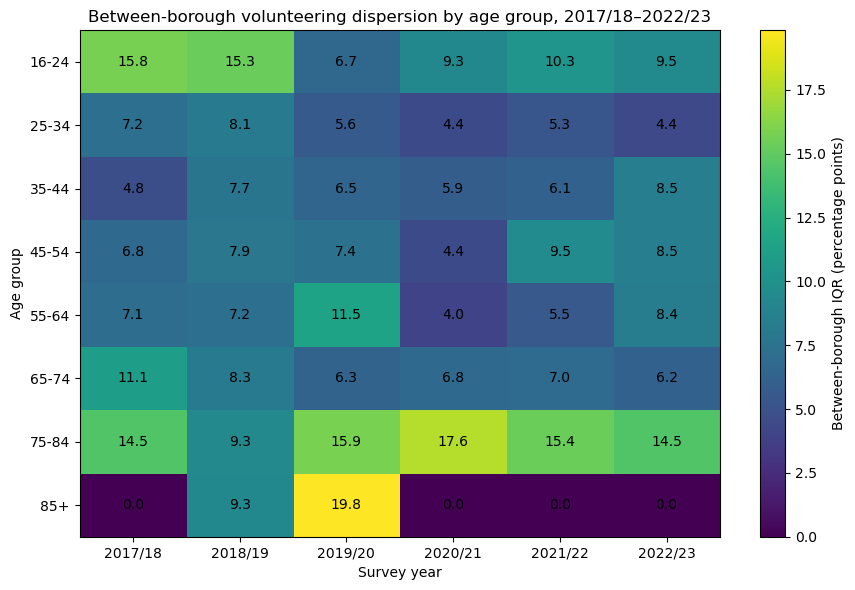

In [22]:
plot_matrix_heatmap(
    data=borough_disparity_age,
    row_column="age_group",
    column_column="year",
    value_column=(
        "borough_iqr"
    ),
    row_order=AGE_ORDER,
    column_order=YEAR_ORDER,
    column_labels=YEAR_LABELS,
    title=(
        f"Between-borough volunteering dispersion by age group, {HISTORICAL_PERIOD_LABEL}"
    ),
    xlabel="Survey year",
    ylabel="Age group",
    colorbar_label=(
        "Between-borough IQR "
        "(percentage points)"
    ),
    filename=(
        "figure_09_age_between_borough_iqr_heatmap.png"
    ),
    figsize=(9, 6),
    value_multiplier=100,
    annotate=True,
)

## Module 8 — Export descriptive tables and final checks

This module exports the descriptive tables used in the historical analysis and performs final range checks.

All volunteering rates must remain within `[0, 1]`. Historical activity-level gaps must remain within `[-1, 1]`, and all between-borough IQR values must be non-negative.

In [23]:
output_tables = {
    "q5_year8_borough_age_baseline.csv":
        year8_borough_age,

    "q5_year8_borough_activity_baseline.csv":
        year8_borough_activity,

    "q5_historical_activity_median.csv":
        historical_activity_median,

    "q5_historical_age_median.csv":
        historical_age_median,

    "q5_borough_activity_historical_slopes.csv":
        borough_activity_slopes,

    "q5_borough_age_historical_slopes.csv":
        borough_age_slopes,

    "q5_borough_age_year_activity_rates_and_gaps.csv":
        borough_age_year_activity_rates,

    "q5_historical_gap_by_age_year.csv":
        historical_gap_by_age_year,

    "q5_between_borough_disparity_activity.csv":
        borough_disparity_activity,

    "q5_between_borough_disparity_age.csv":
        borough_disparity_age,
}

for (
    filename,
    dataframe,
) in output_tables.items():
    output_path = (
        TABLE_DIR
        / filename
    )

    dataframe.to_csv(
        output_path,
        index=False,
    )

    print(
        f"Saved table: "
        f"{output_path}"
    )
    
rate_checks = {
    "Year 8 borough-age baseline":
        year8_borough_age[
            "frequent_volunteer_rate"
        ],

    "Year 8 borough-activity baseline":
        year8_borough_activity[
            "frequent_volunteer_rate"
        ],

    "Historical age medians":
        historical_age_median[
            "median_borough_rate"
        ],

    "Historical activity medians":
        historical_activity_median[
            "median_borough_rate"
        ],
}

for (
    table_name,
    rates,
) in rate_checks.items():
    if not (
        rates
        .dropna()
        .between(
            0,
            1,
        )
        .all()
    ):
        raise ValueError(
            f"Invalid rate found in "
            f"{table_name}."
        )


gap_columns = [
    borough_age_year_activity_rates[
        "active_inactive_gap"
    ],
    borough_age_year_activity_rates[
        "fairly_inactive_gap"
    ],
]

for gaps in gap_columns:
    if not (
        gaps
        .dropna()
        .between(
            -1,
            1,
        )
        .all()
    ):
        raise ValueError(
            "An activity-level gap falls outside [-1, 1]."
        )


disparity_columns = [
    borough_disparity_activity[
        "borough_iqr"
    ],
    borough_disparity_age[
        "borough_iqr"
    ],
]

for disparity in disparity_columns:
    if (
        disparity
        .dropna()
        .lt(0)
        .any()
    ):
        raise ValueError(
            "A between-borough IQR is negative."
        )


print(
    "All historical descriptive checks passed."
)

print(
    f"Figures saved to: "
    f"{FIGURE_DIR}"
)

print(
    f"Tables saved to: "
    f"{TABLE_DIR}"
)

Saved table: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_tables/q5_year8_borough_age_baseline.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_tables/q5_year8_borough_activity_baseline.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_tables/q5_historical_activity_median.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_tables/q5_historical_age_median.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_tables/q5_borough_activity_historical_slopes.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_tables/q5_borough_age_historical_slopes.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_tables/q5_borough_age_year_activity_rates_and_gaps.csv
Saved table: /Users/zsh/Downloads/PROJECT/code/q4_historical_outputs/descriptive_tables/q5_historical_gap_by_age_year.csv